In [3]:
import numpy as np
import astropy.constants as consts
import astropy.units as units
from uncertainties import ufloat
from uncertainties import umath
import matplotlib.pyplot as plt
import re

from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration
from erebus.photometry_data import PhotometryData
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.time import Time
from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture
from scipy.optimize import curve_fit
from uncertainties import ufloat

plt.rcParams.update({
	'font.family': 'serif',
    'font.serif': ['cmr10'],
    'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,    
	'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
})

single_column = (3.5, 2.625)
double_column = (7, 5.25)

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

In [4]:
class Planet:
	def __init__(self, name, L_star, M_star, P, M_p, R_p, atm):
		self.name = name
		self.L_star = L_star
		self.M_star = M_star
		self.P = P
		self.M_p = M_p
		self.R_p = R_p
		self.v_esc = umath.sqrt(2 * consts.G.si.value * (M_p * consts.M_earth).si.value / (R_p * consts.R_earth).si.value) / 1000
		self.a = (((((consts.G * M_star * consts.M_sun) * (P * (1 * units.day))**2) / (4 * np.pi**2))**(1/3)).si / consts.au.si).value
		self.I = self.L_star**0.4 * ((1 / self.a)**2)

		if isinstance(self.I, np.float64):
			self.I = ufloat(self.I, 0)
		if isinstance(self.v_esc, np.float64) or isinstance(self.v_esc, float):
			self.v_esc = ufloat(self.v_esc, 0)

		self.atm = atm


In [17]:
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive
import pandas as pd

planet_list = [
	# DDT Targets
	"GJ 3929 b",
	"LTT 1445 A b",
	"LTT 1445 A c",
	"HD 260655 c",
	"LHS 1140 b",
	"TOI-198 b",
	"TOI-244 b",
	"TOI-406 c",
	"TOI-771 b",
	# Hot rocks targets
	"LHS 1140 c",
	"LTT 3780 b",
	"LHS 1478 b",
	"TOI-1468 b",
	"GJ 3473 b",
	# TRAPPIST-1
	"TRAPPIST-1 b",
	"TRAPPIST-1 c",
]

columns = {
	'pl_name': 'Planet Name',
	
	'pl_orbper': 'Orbital Period',
	'pl_orbpererr1': 'Orbital Period',
	'pl_orbpererr2': 'Orbital Period',
	
	'pl_bmasse': 'Planet Mass',
	'pl_bmasseerr1': 'Planet Mass Err1',
	'pl_bmasseerr2': 'Planet Mass Err2',
	
	'pl_rade': 'Planet Radius',
	'pl_radeerr1': 'Planet Radius Err1',
	'pl_radeerr2': 'Planet Radius Err2',
	
	'st_mass': 'Stellar Mass',
	'st_masserr1': 'Stellar Mass Err1',
	'st_masserr2': 'Stellar Mass Err2',
	
	'st_lum': 'Stellar Luminosity',
	'st_lumerr1': 'Stellar Luminosity Err1',
	'st_lumerr2': 'Stellar Luminosity Err2'
}

ref_cols = [
	'pl_orbper_reflink',
	'pl_bmasse_reflink',
	'pl_rade_reflink',
	'st_mass_reflink',
	'st_lum_reflink',
]

data = NasaExoplanetArchive.query_criteria(
	table='pscomppars',
	select=','.join(list(columns.keys()) + ref_cols),
	where="pl_name in ({})".format(
		', '.join(f"'{planet}'" for planet in planet_list)
	)
)

df = data.to_pandas()

UnitTypeError("MaskedQuantity instances require normal units, not <class 'astropy.units.function.logarithmic.DexUnit'> instances.") [astropy.table.table]
2026-05-20 16:53:22,374 - stpipe - WARNING - column st_lum has a unit but is kept as a MaskedColumn as an attempt to convert it to Quantity failed with:
UnitTypeError("MaskedQuantity instances require normal units, not <class 'astropy.units.function.logarithmic.DexUnit'> instances.")
UnitTypeError("MaskedQuantity instances require normal units, not <class 'astropy.units.function.logarithmic.DexUnit'> instances.") [astropy.table.table]
2026-05-20 16:53:22,385 - stpipe - WARNING - column st_lumerr1 has a unit but is kept as a MaskedColumn as an attempt to convert it to Quantity failed with:
UnitTypeError("MaskedQuantity instances require normal units, not <class 'astropy.units.function.logarithmic.DexUnit'> instances.")
UnitTypeError("MaskedQuantity instances require normal units, not <class 'astropy.units.function.logarithmic.DexUnit'>

In [18]:
# Checking all references for the parameters used
all_refs = []
for col in ref_cols:
	if col in df.columns:
		for _, row in df.iterrows():
			val = row[col]
			if pd.notna(val):
				matches = re.findall(r'href=(https?://\S+?)[\s>]', str(val))
				for url in matches:
					planet = row['pl_name']
					all_refs.append((planet, url))

print("Planet, Reference URL")
unique_urls = set()
planet_url_dict = dict()
for planet, url in sorted(all_refs):
	unique_urls.update([url])
	planet_url_dict[url] = planet

for unique_url in sorted(unique_urls):
	print(unique_url, planet_url_dict[unique_url])

bibliography_codes = [url.split('/')[4] for url in unique_urls]
print(", ".join(bibliography_codes))

Planet, Reference URL
https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract LTT 1445 A c
https://ui.adsabs.harvard.edu/abs/2020A&A...642A.236K/abstract GJ 3473 b
https://ui.adsabs.harvard.edu/abs/2021A&A...649A.144S/abstract LHS 1478 b
https://ui.adsabs.harvard.edu/abs/2021PSJ.....2....1A/abstract TRAPPIST-1 c
https://ui.adsabs.harvard.edu/abs/2022A&A...664A.199L/abstract HD 260655 c
https://ui.adsabs.harvard.edu/abs/2022AJ....163..168W/abstract LTT 1445 A c
https://ui.adsabs.harvard.edu/abs/2022ApJ...936...55B/abstract GJ 3929 b
https://ui.adsabs.harvard.edu/abs/2023A&A...675A..52C/abstract TOI-244 b
https://ui.adsabs.harvard.edu/abs/2023AJ....166..171P/abstract LTT 1445 A b
https://ui.adsabs.harvard.edu/abs/2024A&A...682A..66B/abstract LTT 3780 b
https://ui.adsabs.harvard.edu/abs/2024A&A...692A.238L/abstract TOI-406 c
https://ui.adsabs.harvard.edu/abs/2024ApJ...960L...3C/abstract LHS 1140 c
https://ui.adsabs.harvard.edu/abs/2025A&A...698A..68M/abstract TOI-1468 b
https://ui.

In [23]:
Earth = Planet("Earth", 1, 1, 365, 1, 1, "yes")
Venus = Planet("Venus", 1, 1, 225, 0.82, 0.95, "yes")
Mars = Planet("Mars", 1, 1, 687, 0.107, 0.532, "yes")

planets = []

def read_value(row, name):
	val = row[name]
	err = np.max(np.abs([row[name + "err1"], row[name + "err2"]]))
	return ufloat(val, err)

possible = ["LHS 1478 b", "TRAPPIST-1 c"]
no = ["GJ 3929 b", "LHS 1140 c", "TOI-1468 b", "TRAPPIST-1 b", "LTT 3780 b", "GJ 3473 b"]

no_duplicates = []
for p in planet_list:
	try:
		print(p)
		row = df[df['pl_name'] == p]
		P = read_value(row, 'pl_orbper')
		M_p = read_value(row, 'pl_bmasse')
		R_p = read_value(row, 'pl_rade')
		L_s = 10**read_value(row, 'st_lum')
		M_s = read_value(row, 'st_mass')
		atm = "yes" if p in possible else ("no" if p in no else "tbd")
		if p == "GJ 3929 b":
			M_p = ufloat(1.13, 0.09)
			R_p = ufloat(1.09, 0.04)
		if p == "TOI-198 b":
			V = (4/3.0) * np.pi * (R_p * consts.R_earth.to(units.cm).value)**3
			M_p = (5.51 * V) / (consts.M_earth.to(units.g).value)
			print(M_p)
		planet = Planet(p, L_s, M_s, P, M_p, R_p, atm)

		if planet.name in no_duplicates:
			print(f"{planet.name} was added to the list twice")
			continue
		
		no_duplicates.append(planet.name)
		planets.append(planet)
	except:
		print("Couldn't load planet " + p)

2026-05-20 16:54:02,206 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")

2026-05-20 16:54:02,214 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  value = float(value)



GJ 3929 b
LTT 1445 A b
LTT 1445 A c
HD 260655 c
LHS 1140 b
TOI-198 b
2.5+/-0.7
TOI-244 b
TOI-406 c
TOI-771 b
LHS 1140 c
LTT 3780 b
LHS 1478 b
TOI-1468 b
GJ 3473 b
TRAPPIST-1 b
TRAPPIST-1 c


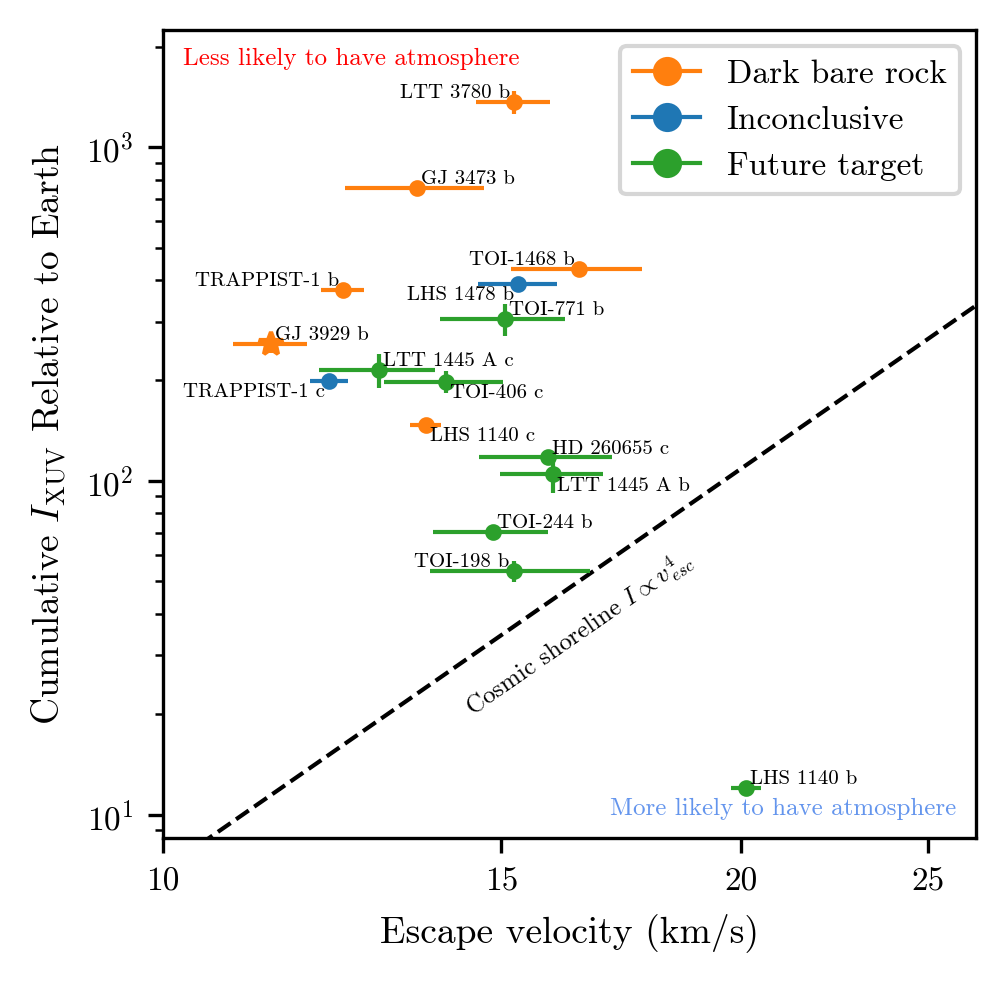

In [25]:
bare_rock = 'C1'
inconclusive = 'C0'
future = 'C2'

plt.figure(figsize=(3.5, 3.5))

# Annotation alignment
ha_right = ['TOI-1468 b', 'TOI-198 b', 'TRAPPIST-1 c', 'TRAPPIST-1 b', 'LHS 1478 b', 'LTT 3780 b']
down = ["LHS 1478 b", "TRAPPIST-1 c", "LTT 1445 A b", "TOI-406 c", "LHS 1140 c"]

for p in planets:
	color = inconclusive if p.atm == "yes" else (bare_rock if p.atm == "no" else future)
	plt.errorbar([p.v_esc.nominal_value], [p.I.nominal_value], xerr=[p.v_esc.std_dev], yerr=[p.I.std_dev], \
				 marker='.' if p.name != "GJ 3929 b" else "*", \
				 color=color)
	plt.annotate("" + p.name, (p.v_esc.nominal_value, p.I.nominal_value), 
				 xytext=(-4 if p.name in ha_right else 4, -16 if p.name in down else 4), textcoords='offset pixels', \
				 ha = "right" if p.name in ha_right else "left",
				 fontweight= "bold" if p.name == "GJ 3929 b" else "normal",
				fontsize = 5)

plt.errorbar([], [], marker='o', label="Dark bare rock", color=bare_rock)
plt.errorbar([], [], marker='o', label="Inconclusive", color=inconclusive)
plt.errorbar([], [], marker='o', label="Future target", color=future)

plt.legend(loc="upper right")

escapes = [p.v_esc.nominal_value for p in planets]

x = np.linspace(np.min(escapes) - 4, np.max(escapes) + 10, 1000)
power = 4
y = x**power
y = y * Mars.I.nominal_value / Mars.v_esc.nominal_value**power

plt.plot(x, y, linestyle='--', color='black', alpha=1, zorder=1)

plt.xlabel("Escape velocity (km/s)")
plt.ylabel(r"Cumulative $I_{\mathrm{XUV}}$ Relative to Earth")
plt.xticks()
plt.yticks()
plt.loglog()
plt.xticks([10, 15, 20, 25])
plt.gca().set_xticklabels(["10", "15", "20", "25"])
plt.gca().xaxis.set_minor_locator(plt.NullLocator())

plt.xlim([10, 26.5])
plt.ylim([8.5, 2250])

start = plt.gca().transData.transform((np.min(x), np.min(y)))
end = plt.gca().transData.transform((np.max(x), np.max(y)))

plt.gca().text(0.975, 0.05, 'More likely to have atmosphere', transform=plt.gca().transAxes, color='cornflowerblue', ha='right', va='top', fontsize=6)
plt.gca().text(0.025, 0.95, 'Less likely to have atmosphere', transform=plt.gca().transAxes, color='red', ha='left', va='bottom', fontsize=6)

dx = end[0] - start[0]
dy = end[1] - start[1]
angle = np.arctan2(dy, dx)

plt.annotate("\n\n\n\n\n" + r"Cosmic shoreline $I \propto v_{esc}^4$", (x[len(x)//4], y[len(y)//4]), rotation=angle * 180 / np.pi, fontsize=6)
plt.savefig("figures/cosmic_shoreline_gj3929b.pdf", bbox_inches='tight')
plt.savefig("figures/cosmic_shoreline_gj3929b.png", bbox_inches='tight')
plt.show()